# Titanic Survival Prediction Using Machine Learning

## Objective

The objective of this project is to build a machine learning model that predicts whether a passenger survived the Titanic disaster based on passenger information. The project includes data preprocessing, feature engineering, model training, prediction, and performance evaluation.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import os

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [10]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
IMAGE_DIR = PROJECT_ROOT / "images"

IMAGE_DIR.mkdir(exist_ok=True)

In [11]:
df = pd.read_csv(DATA_DIR / "cleaned_titanic.csv")

In [13]:
df = pd.read_csv(DATA_DIR / "Titanic-Dataset.csv")

In [14]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [17]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [18]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0.0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0.0


## Feature Selection

The input features are selected to predict passenger survival. The target variable is **Survived**.

In [20]:
# Select input features
X = df[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]]

# Target variable
y = df["Survived"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (891, 7)
Target Shape: (891,)


## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (712, 7)
Testing Data: (179, 7)


## Decision Tree Classifier

A Decision Tree model is trained using the training dataset.

In [22]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


## Random Forest Classifier

A Random Forest model is trained to improve prediction performance.

In [23]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [24]:
dt_predictions = decision_tree.predict(X_test)

rf_predictions = random_forest.predict(X_test)

In [25]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Decision Tree Accuracy :", round(dt_accuracy*100,2), "%")
print("Random Forest Accuracy :", round(rf_accuracy*100,2), "%")

Decision Tree Accuracy : 80.45 %
Random Forest Accuracy : 82.68 %


## Classification Report

The classification report provides Precision, Recall, F1-Score, and Accuracy for evaluating the model's performance.

In [26]:
print("Decision Tree Classification Report")
print(classification_report(y_test, dt_predictions))

print("\n" + "="*60 + "\n")

print("Random Forest Classification Report")
print(classification_report(y_test, rf_predictions))

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       105
           1       0.77      0.74      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



## Confusion Matrix

The confusion matrix visualizes the number of correct and incorrect predictions made by the Random Forest model.

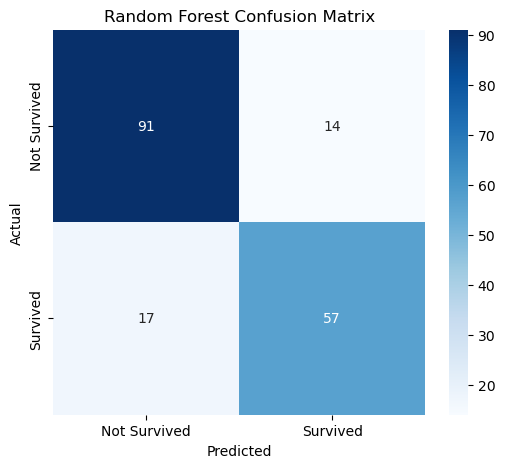

In [27]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, rf_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    IMAGE_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## ROC Curve

The ROC Curve evaluates the classification performance of the Random Forest model.

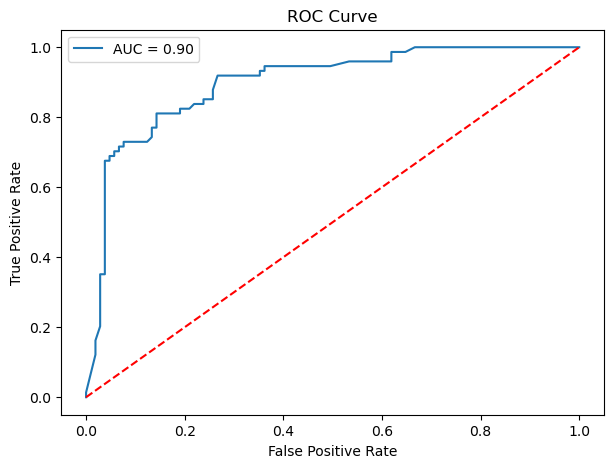

In [28]:
rf_prob = random_forest.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

auc_score = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.savefig(
    IMAGE_DIR / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Feature Importance

This chart displays the importance of each feature used by the Random Forest model.

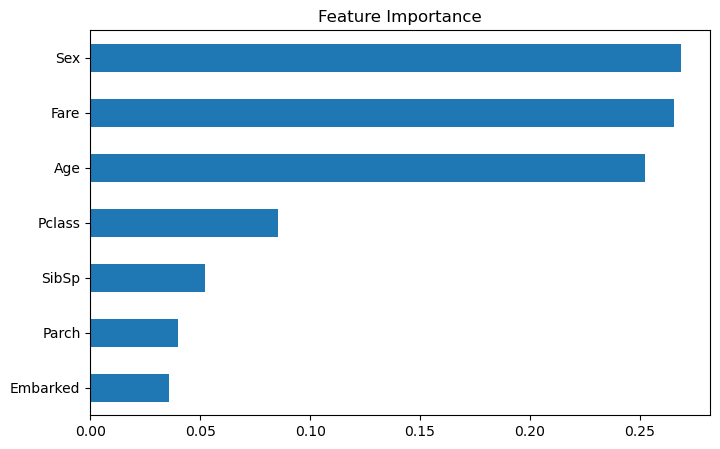

In [29]:
importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.savefig(
    IMAGE_DIR / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Model Accuracy Comparison

Comparison of the accuracy achieved by Decision Tree and Random Forest models.

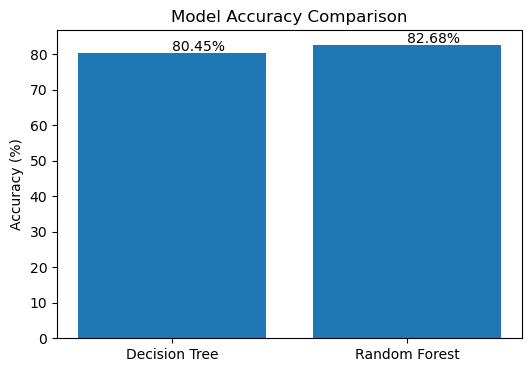

In [30]:
models = ["Decision Tree", "Random Forest"]

accuracy = [
    dt_accuracy*100,
    rf_accuracy*100
]

plt.figure(figsize=(6,4))

plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

for i, value in enumerate(accuracy):
    plt.text(i, value+0.5, f"{value:.2f}%")

plt.savefig(
    IMAGE_DIR / "model_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Sample Prediction

Predict whether a sample passenger would survive based on the trained Random Forest model.

In [32]:
sample = pd.DataFrame({
    "Pclass": [3],
    "Sex": [0],      # Male
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": [0]  # Southampton
})

prediction = random_forest.predict(sample)

if prediction[0] == 1:
    print("Prediction: Passenger Survived")
else:
    print("Prediction: Passenger Did Not Survive")

Prediction: Passenger Did Not Survive


In [34]:
import joblib

joblib.dump(random_forest, "titanic_random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!
